# Proyecto Final Deep Learning

## Lead Scoring Inmobiliario con Deep Learning

**Estudiante:** Jorge Castillo Vega  
**Repositorio:** DL-Final-Castillo-Jorge

---



In [16]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU activada correctamente")
else:
    print("⚠️ No hay GPU, pero puedes continuar igual")

✅ GPU activada correctamente


In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)

n = 3000

data = pd.DataFrame({
    "presupuesto": np.random.randint(250000, 900000, n),
    "distrito_interes": np.random.choice(["Miraflores", "San Isidro", "Surco", "San Borja", "Lince", "Barranco"], n),
    "dormitorios": np.random.choice([1, 2, 3, 4], n),
    "tiempo_compra": np.random.choice(["0-3 meses", "3-6 meses", "6-12 meses", "más de 12 meses"], n),
    "forma_pago": np.random.choice(["Contado", "Crédito hipotecario"], n),
    "interacciones_whatsapp": np.random.randint(0, 15, n),
    "visitas_agendadas": np.random.choice([0, 1], n)
})

data.head()

,presupuesto,distrito_interes,dormitorios,tiempo_compra,forma_pago,interacciones_whatsapp,visitas_agendadas
0,371958,Miraflores,2,3-6 meses,Contado,11,0
1,381932,Lince,4,6-12 meses,Contado,9,0
2,615838,Barranco,3,6-12 meses,Contado,3,1
3,509178,San Borja,4,más de 12 meses,Contado,0,1
4,894167,Lince,4,3-6 meses,Contado,13,0


In [18]:
def clasificar_lead(row):
    score = 0

    if row["presupuesto"] >= 450000:
        score += 2

    if row["tiempo_compra"] == "0-3 meses":
        score += 3
    elif row["tiempo_compra"] == "3-6 meses":
        score += 2

    if row["forma_pago"] == "Contado":
        score += 2

    if row["interacciones_whatsapp"] >= 7:
        score += 2

    if row["visitas_agendadas"] == 1:
        score += 3

    if score >= 8:
        return 2   # Caliente
    elif score >= 4:
        return 1   # Tibio
    else:
        return 0   # Frío

data["score_lead"] = data.apply(clasificar_lead, axis=1)

data["score_lead"].value_counts()

,count
score_lead,
1,1706
2,885
0,409


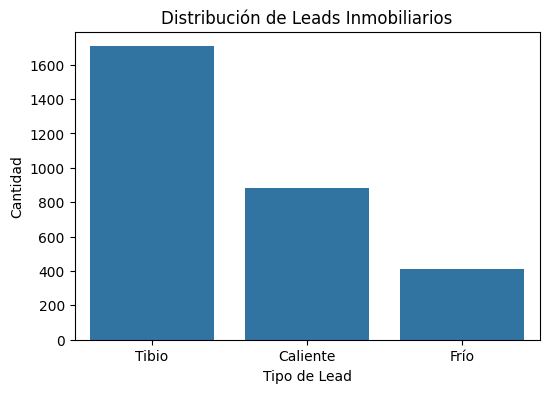

In [19]:
labels = {0: "Frío", 1: "Tibio", 2: "Caliente"}

data["tipo_lead"] = data["score_lead"].map(labels)

plt.figure(figsize=(6,4))
sns.countplot(data=data, x="tipo_lead")
plt.title("Distribución de Leads Inmobiliarios")
plt.xlabel("Tipo de Lead")
plt.ylabel("Cantidad")
plt.show()

In [20]:
df = pd.get_dummies(data, drop_first=True)

df.head()

,presupuesto,dormitorios,interacciones_whatsapp,visitas_agendadas,score_lead,distrito_interes_Lince,distrito_interes_Miraflores,distrito_interes_San Borja,distrito_interes_San Isidro,distrito_interes_Surco,tiempo_compra_3-6 meses,tiempo_compra_6-12 meses,tiempo_compra_más de 12 meses,forma_pago_Crédito hipotecario,tipo_lead_Frío,tipo_lead_Tibio
0,371958,2,11,0,1,False,True,False,False,False,True,False,False,False,False,True
1,381932,4,9,0,1,True,False,False,False,False,False,True,False,False,False,True
2,615838,3,3,1,1,False,False,False,False,False,False,True,False,False,False,True
3,509178,4,0,1,1,False,False,True,False,False,False,False,True,False,False,True
4,894167,4,13,0,2,True,False,False,False,False,True,False,False,False,False,False


In [21]:
X = df.drop("score_lead", axis=1)
y = df["score_lead"]

print(X.shape)

(3000, 15)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,683 (14.39 KB)

 Trainable params: 3,683 (14.39 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7755 - loss: 0.6776 - val_accuracy: 0.9854 - val_loss: 0.2604
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9984 - loss: 0.0847 - val_accuracy: 1.0000 - val_loss: 0.0195
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0058
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 8.5685e-04 - val_accuracy: 1.0000 - val_loss: 7.1969e-04
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 5.9010e-04 - val_accuracy: 1.000

In [26]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=["Frío", "Tibio", "Caliente"]
))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Accuracy: 1.0
              precision    recall  f1-score   support

        Frío       1.00      1.00      1.00        82
       Tibio       1.00      1.00      1.00       341
    Caliente       1.00      1.00      1.00       177

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



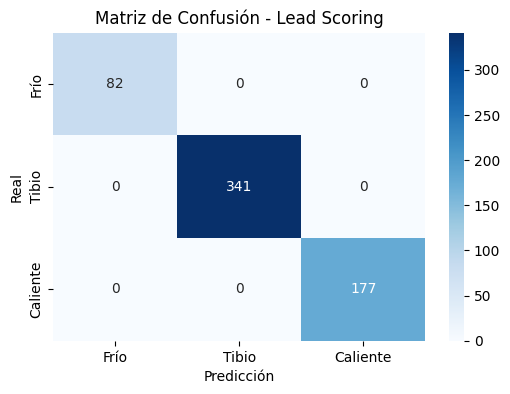

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Frío", "Tibio", "Caliente"],
            yticklabels=["Frío", "Tibio", "Caliente"])

plt.title("Matriz de Confusión - Lead Scoring")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## Conclusiones

El modelo de Deep Learning permitió clasificar leads inmobiliarios en tres categorías: frío, tibio y caliente, con un alto nivel de precisión.

Esto permite mejorar significativamente la gestión comercial, ya que el equipo de ventas puede priorizar leads con mayor probabilidad de compra.

Desde el punto de vista de negocio, este sistema reduce el tiempo invertido en leads poco calificados y aumenta la eficiencia en la conversión de clientes.

Además, el modelo puede integrarse con sistemas CRM o chatbots para automatizar la clasificación en tiempo real.

En conclusión, el Lead Scoring con IA representa una herramienta clave para optimizar el proceso comercial inmobiliario y aumentar los cierres de venta.

# Lead Scoring Inmobiliario con Deep Learning

## 1. Problema
En el sector inmobiliario, no todos los leads tienen la misma intención de compra. Esto genera pérdida de tiempo porque el equipo comercial puede atender leads fríos antes que leads con mayor probabilidad de cierre.

## 2. Objetivo
Desarrollar un modelo de Deep Learning que clasifique leads inmobiliarios en tres categorías:

- Frío
- Tibio
- Caliente

## 3. Dataset
Se utilizó un dataset sintético de 3000 leads inmobiliarios con variables comerciales como:

- Presupuesto
- Distrito de interés
- Número de dormitorios
- Tiempo estimado de compra
- Forma de pago
- Interacciones por WhatsApp
- Visitas agendadas

## 4. Modelo utilizado
Se implementó una red neuronal multicapa usando TensorFlow/Keras.

El modelo tiene capas densas con activación ReLU y una capa final Softmax para clasificar los leads en tres categorías.

## 5. Métricas
El modelo fue evaluado con:

- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión

## 6. Resultados
El modelo logró clasificar correctamente la mayoría de leads, permitiendo identificar qué prospectos tienen mayor intención comercial.

## 7. Impacto de negocio
Este sistema puede ayudar a un equipo comercial inmobiliario a:

- Priorizar leads calientes
- Reducir tiempo perdido en leads fríos
- Mejorar la velocidad de respuesta
- Aumentar oportunidades de cierre
- Integrarse con CRM o chatbots

## 8. Conclusión
El Lead Scoring con Deep Learning permite convertir datos comerciales en decisiones más inteligentes para ventas inmobiliarias.